# FIGS2: Pairwise Statistical Comparison of Inverse-Dynamics Accuracy

This notebook regenerates Supplementary Figure 2 from the packaged data archive `FIGS2.zip` or `FIGS2`.
The archive must be in the same folder as this notebook. No synthetic or placeholder data are generated.

Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIGS2.svg


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIGS2.pdf


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIGS2.png


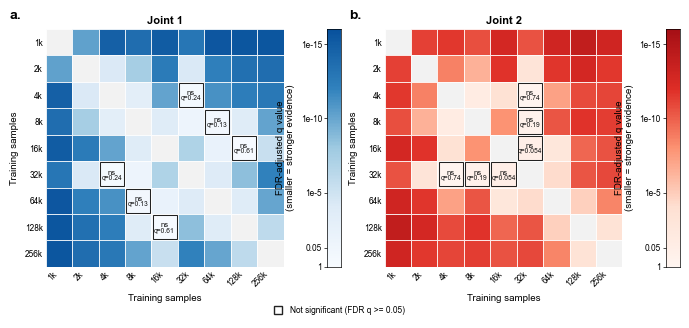

Data provenance:
  no_fake_data_generated = True
  RMSE rows = 900
  pairwise comparisons = 72
  significant counts = {'J1': 33, 'J2': 33}
Non-significant pairs:
  J1: [{'dataset_label_a': '4k', 'dataset_label_b': '32k', 'fdr_q_value': 0.2410635058509898}, {'dataset_label_a': '8k', 'dataset_label_b': '64k', 'fdr_q_value': 0.12711362693965442}, {'dataset_label_a': '16k', 'dataset_label_b': '128k', 'fdr_q_value': 0.6123683054421181}]
  J2: [{'dataset_label_a': '4k', 'dataset_label_b': '32k', 'fdr_q_value': 0.7381152654468986}, {'dataset_label_a': '8k', 'dataset_label_b': '32k', 'fdr_q_value': 0.18511181411727703}, {'dataset_label_a': '16k', 'dataset_label_b': '32k', 'fdr_q_value': 0.05363383210702798}]


In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIGS2.zip or FIGS2 must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIGS2.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIGS2")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIGS2.zip or FIGS2 in the current folder. "
        "Place the data archive in the same folder as FIGS2.ipynb."
    )

with zipfile.ZipFile(DATA_ARCHIVE) as archive:
    rmse_values = pd.read_csv(archive.open("figs2_rmse_values.csv"))
    pairwise_statistics = pd.read_csv(archive.open("figs2_pairwise_statistics.csv"))
    q_matrices = {
        "J1": pd.read_csv(archive.open("figs2_fdr_q_matrix_J1.csv"), index_col=0),
        "J2": pd.read_csv(archive.open("figs2_fdr_q_matrix_J2.csv"), index_col=0),
    }
    metadata = json.load(archive.open("figs2_metadata.json"))

DATASET_SIZES = [int(v) for v in metadata["dataset_sizes"]]
DATASET_LABELS = [str(v) for v in metadata["dataset_labels"]]
ALPHA = float(metadata["alpha"])
for joint in q_matrices:
    q_matrices[joint].index = q_matrices[joint].index.astype(int)
    q_matrices[joint].columns = q_matrices[joint].columns.astype(int)
    q_matrices[joint] = q_matrices[joint].loc[DATASET_SIZES, DATASET_SIZES]

# -----------------------------------------------------------------------------
# Style and helpers.
# -----------------------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.55,
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 600,
})

joint_cmaps = {
    "J1": mpl.colors.LinearSegmentedColormap.from_list(
        "joint1_q_blue", ["#F7FBFF", "#DEEBF7", "#9ECAE1", "#3182BD", "#08519C"]
    ),
    "J2": mpl.colors.LinearSegmentedColormap.from_list(
        "joint2_q_red", ["#FFF5F0", "#FEE0D2", "#FC9272", "#DE2D26", "#A50F15"]
    ),
}

all_q_values = np.concatenate([
    matrix.to_numpy(dtype=float)[np.isfinite(matrix.to_numpy(dtype=float))]
    for matrix in q_matrices.values()
])
max_score = float(np.ceil(np.nanmax(-np.log10(all_q_values))))
max_score = max(max_score, -np.log10(ALPHA), 15.0)
norm = mpl.colors.Normalize(vmin=0.0, vmax=max_score)


def draw_pairwise_matrix(ax, q_matrix, title, cmap):
    dataset_sizes = list(q_matrix.index.astype(int))
    n = len(dataset_sizes)
    ax.set_xlim(0, n)
    ax.set_ylim(n, 0)
    ax.set_aspect("equal")

    for i, size_a in enumerate(dataset_sizes):
        for j, size_b in enumerate(dataset_sizes):
            q_value = q_matrix.loc[size_a, size_b]
            if i == j or not np.isfinite(q_value):
                rect = Rectangle((j, i), 1, 1, facecolor="#F2F2F2", edgecolor="white", linewidth=0.55)
                ax.add_patch(rect)
                continue

            score = -np.log10(max(float(q_value), np.finfo(float).tiny))
            rect = Rectangle((j, i), 1, 1, facecolor=cmap(norm(score)), edgecolor="white", linewidth=0.55)
            ax.add_patch(rect)

            if float(q_value) >= ALPHA:
                outline = Rectangle((j + 0.045, i + 0.045), 0.91, 0.91,
                                    facecolor="none", edgecolor="#222222", linewidth=0.75)
                ax.add_patch(outline)
                ax.text(j + 0.5, i + 0.43, "ns", ha="center", va="center",
                        fontsize=5.5, color="#111111")
                ax.text(j + 0.5, i + 0.62, f"q={q_value:.2g}", ha="center", va="center",
                        fontsize=4.8, color="#111111")

    tick_positions = np.arange(n) + 0.5
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(DATASET_LABELS, rotation=45, ha="right")
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(DATASET_LABELS)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("Training samples")
    ax.set_title(title, fontsize=8, fontweight="bold", pad=4)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0, pad=2)


def draw_vector_colorbar(ax, cmap):
    # Draw colorbar as editable rectangles rather than a raster gradient.
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max_score)
    segments = 160
    edges = np.linspace(0, max_score, segments + 1)
    for low, high in zip(edges[:-1], edges[1:]):
        mid = 0.5 * (low + high)
        ax.add_patch(Rectangle((0, low), 1, high - low,
                               facecolor=cmap(norm(mid)), edgecolor="none", linewidth=0))
    ax.set_xticks([])
    tick_scores = [0, -np.log10(ALPHA), 5, 10, 15]
    tick_labels = ["1", "0.05", "1e-5", "1e-10", "1e-15"]
    ax.set_yticks(tick_scores)
    ax.set_yticklabels(tick_labels)
    ax.set_ylabel("FDR-adjusted q value\n(smaller = stronger evidence)")
    ax.tick_params(axis="y", direction="out", length=2.0, width=0.5, pad=2)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)

# -----------------------------------------------------------------------------
# Plot Supplementary Figure 2.
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(7.20, 3.35), constrained_layout=False)
gs = fig.add_gridspec(
    nrows=1,
    ncols=4,
    width_ratios=[1.0, 0.045, 1.0, 0.045],
    left=0.055,
    right=0.975,
    top=0.90,
    bottom=0.19,
    wspace=0.10,
)
ax_j1 = fig.add_subplot(gs[0, 0])
cax_j1 = fig.add_subplot(gs[0, 1])
ax_j2 = fig.add_subplot(gs[0, 2])
cax_j2 = fig.add_subplot(gs[0, 3])

draw_pairwise_matrix(ax_j1, q_matrices["J1"], "Joint 1", joint_cmaps["J1"])
draw_pairwise_matrix(ax_j2, q_matrices["J2"], "Joint 2", joint_cmaps["J2"])
draw_vector_colorbar(cax_j1, joint_cmaps["J1"])
draw_vector_colorbar(cax_j2, joint_cmaps["J2"])

ax_j1.text(-0.15, 1.03, "a.", transform=ax_j1.transAxes, fontsize=10,
           fontweight="bold", va="bottom", ha="left")
ax_j2.text(-0.15, 1.03, "b.", transform=ax_j2.transAxes, fontsize=10,
           fontweight="bold", va="bottom", ha="left")

legend_handle = Line2D([0], [0], marker="s", markersize=6, markerfacecolor="white",
                       markeredgecolor="#222222", linestyle="none",
                       label=f"Not significant (FDR q >= {ALPHA:g})")
fig.legend(handles=[legend_handle], loc="lower center", bbox_to_anchor=(0.5, 0.025),
           frameon=False, fontsize=6, handletextpad=0.4)

for ext in ["svg", "pdf", "png"]:
    path = Path(f"FIGS2.{ext}")
    if ext == "png":
        fig.savefig(path, dpi=600, bbox_inches="tight", pad_inches=0.03, facecolor="white")
    else:
        fig.savefig(path, bbox_inches="tight", pad_inches=0.03, facecolor="white")
    print(f"Saved {path.resolve()}")

plt.show()

print("Data provenance:")
print(f"  no_fake_data_generated = {metadata['no_fake_data_generated']}")
print(f"  RMSE rows = {metadata['num_rmse_rows']}")
print(f"  pairwise comparisons = {metadata['num_pairwise_rows']}")
print(f"  significant counts = {metadata['significant_counts_by_joint']}")
print("Non-significant pairs:")
for joint, pairs in metadata["nonsignificant_pairs_by_joint"].items():
    print(f"  {joint}: {pairs}")